# 06 — GARCH Volatility Model

---

## Why GARCH?

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models
capture **volatility clustering** — the empirical observation that large
price moves tend to cluster together.

| Aspect | GARCH | ML Models |
|--------|-------|----------|
| Models | Conditional variance | Conditional mean |
| Captures | Vol clustering, fat tails | Feature interactions |
| Output | Return + Volatility forecast | Return forecast only |
| Use case | Position sizing, risk, VaR | Direction prediction |

## Mathematical Foundation

**Mean model:** $r_t = \mu + \phi_1 r_{t-1} + \epsilon_t$ (AR(1))

**Variance model:** $\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$ (GARCH(1,1))

Where:
- $\alpha$ = ARCH effect (how much yesterday's shock affects today's volatility)
- $\beta$ = GARCH effect (persistence of volatility)
- $\alpha + \beta$ close to 1 = highly persistent volatility (typical for stocks)
- Innovation distribution: Student-t (captures fat tails better than Gaussian)

## Dual Output

GARCH provides two signals for the ensemble:
1. **Conditional mean return** → ensemble prediction column
2. **Conditional volatility** → position sizing (invest less when vol is high)

---
*Educational project. Not financial advice.*

In [31]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

from src.models.garch_model import GARCHModel
from src.features.pipeline import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Processed Data

In [32]:
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.NS.parquet"))

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

print(f"Loaded {len(all_data)} tickers")
sample_tickers = list(all_data.keys())
print(f"Training on {len(sample_tickers)} tickers")

Loaded 122 tickers
Training on 122 tickers


## Step 2 — Prepare Panel Data with Ticker Identity

In [33]:
target_horizon = 5  # 5-day return

all_features = []
all_targets = []

for ticker in sample_tickers:
    df = all_data[ticker]
    
    # Create target: forward return
    target = df["Close"].shift(-target_horizon) / df["Close"] - 1
    valid = target.dropna().index
    
    if len(valid) > 200:
        feat_df = pd.DataFrame(index=valid)
        feat_df["_ticker"] = ticker
        feat_df["_date"] = valid
        feat_df["_close"] = df.loc[valid, "Close"]
        # Also store daily return for GARCH fitting
        feat_df["_daily_ret"] = df.loc[valid, "Close"].pct_change()
        all_features.append(feat_df)
        all_targets.append(target.loc[valid])

X_all = pd.concat(all_features).reset_index(drop=True)
y_all = pd.concat(all_targets).reset_index(drop=True)

dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]

# Sort by date
sort_order = dates_col.argsort()
X_all = X_all.iloc[sort_order].reset_index(drop=True)
y_all = y_all.iloc[sort_order].reset_index(drop=True)
dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]

print(f"Total samples:  {len(X_all):,}")
print(f"Tickers:        {len(X_all['_ticker'].unique())}")
print(f"Date range:     {dates_col.min().date()} → {dates_col.max().date()}")
print(f"Target mean:    {y_all.mean():.4f}")
print(f"Target std:     {y_all.std():.4f}")

Total samples:  253,768
Tickers:        121
Date range:     2016-12-09 → 2026-02-04
Target mean:    0.0049
Target std:     0.0491


## Step 3 — Walk-Forward Training (Per-Ticker GARCH)

For each fold:
1. Split data by calendar date (expanding window)
2. Fit GARCH(1,1) per-ticker on training returns
3. Forecast conditional mean and volatility
4. Record OOF predictions for ensemble

In [34]:
unique_dates = sorted(dates_col.unique())
n_dates = len(unique_dates)

train_days = 504
test_days = 63
embargo_days = 5
step_days = 252  # ~1 year step → ~5 folds (practical for GARCH's per-ticker fitting)

fold_results = []
fold_predictions = []
fold_vol_predictions = []  # Extra: volatility forecasts
fold_num = 0

total_start = time.time()
idx = 0
while idx + train_days + embargo_days + test_days <= n_dates:
    fold_num += 1
    
    train_end_idx = idx + train_days
    test_start_idx = train_end_idx + embargo_days
    test_end_idx = test_start_idx + test_days
    
    if test_end_idx > n_dates:
        break
    
    # Expanding window
    train_dates_set = set(unique_dates[0:train_end_idx])
    test_dates_set = set(unique_dates[test_start_idx:test_end_idx])
    
    train_mask = dates_col.isin(train_dates_set)
    test_mask = dates_col.isin(test_dates_set)
    
    X_train = X_all[train_mask.values]
    y_train = y_all[train_mask.values]
    X_test = X_all[test_mask.values]
    y_test = y_all[test_mask.values]
    
    if len(X_train) < 200 or len(X_test) < 30:
        idx += step_days
        continue
    
    print(f"\n--- Fold {fold_num} ---")
    print(f"  Train: {unique_dates[0].date()} → {unique_dates[train_end_idx-1].date()} ({len(X_train):,} samples)")
    print(f"  Test:  {unique_dates[test_start_idx].date()} → {unique_dates[min(test_end_idx-1, n_dates-1)].date()} ({len(X_test):,} samples)")
    
    # Fit GARCH per-ticker
    fold_start = time.time()
    model = GARCHModel()
    metrics = model.fit(X_train, y_train)
    fold_time = time.time() - fold_start
    print(f"  Fitted {metrics['fitted_tickers']}/{metrics['total_tickers']} tickers in {fold_time:.0f}s")
    
    # Predict returns
    y_pred = model.predict(X_test)
    vol_pred = model.predict_volatility(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    direction_acc = accuracy_score(y_test > 0, y_pred > 0)
    
    fold_results.append({
        "fold": fold_num,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "direction_accuracy": direction_acc,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "fitted_tickers": metrics['fitted_tickers'],
        "avg_predicted_vol": vol_pred.mean(),
    })
    
    test_dates_vals = dates_col[test_mask.values]
    test_tickers_vals = tickers_col[test_mask.values]
    fold_predictions.append(pd.DataFrame({
        "date": test_dates_vals.values,
        "Ticker": test_tickers_vals.values,
        "actual": y_test.values,
        "predicted": y_pred,
        "predicted_vol": vol_pred,
        "fold": fold_num,
    }))
    
    print(f"  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}  Dir Acc: {direction_acc:.1%}")
    print(f"  Avg predicted vol: {vol_pred.mean():.4f}")
    
    idx += step_days
    gc.collect()

total_time = time.time() - total_start
results_df = pd.DataFrame(fold_results)
print(f"\n{'='*60}")
print(f"TOTAL TIME: {total_time/60:.1f} minutes")
print(f"AVERAGE ACROSS {len(fold_results)} FOLDS:")
print(f"  RMSE:              {results_df['rmse'].mean():.4f}  ± {results_df['rmse'].std():.4f}")
print(f"  MAE:               {results_df['mae'].mean():.4f}  ± {results_df['mae'].std():.4f}")
print(f"  R²:                {results_df['r2'].mean():.4f}  ± {results_df['r2'].std():.4f}")
print(f"  Direction Accuracy: {results_df['direction_accuracy'].mean():.1%}  ± {results_df['direction_accuracy'].std():.1%}")
print(f"  Avg Predicted Vol:  {results_df['avg_predicted_vol'].mean():.4f}")


--- Fold 1 ---
  Train: 2016-12-09 → 2018-12-20 (50,634 samples)
  Test:  2018-12-31 → 2019-04-02 (6,713 samples)
  Fitted 104/105 tickers in 2s
  RMSE: 0.0987  MAE: 0.0698  R²: -3.5736  Dir Acc: 49.9%
  Avg predicted vol: 0.0354

--- Fold 2 ---
  Train: 2016-12-09 → 2020-01-03 (77,738 samples)
  Test:  2020-01-13 → 2020-04-16 (6,893 samples)
  Fitted 108/108 tickers in 2s
  RMSE: 0.1296  MAE: 0.0932  R²: -1.2086  Dir Acc: 50.8%
  Avg predicted vol: 0.0346

--- Fold 3 ---
  Train: 2016-12-09 → 2021-01-06 (105,590 samples)
  Test:  2021-01-14 → 2021-04-19 (7,056 samples)
  Fitted 111/112 tickers in 2s
  RMSE: 0.1740  MAE: 0.1268  R²: -8.7455  Dir Acc: 50.5%
  Avg predicted vol: 0.0429

--- Fold 4 ---
  Train: 2016-12-09 → 2022-01-12 (134,112 samples)
  Test:  2022-01-20 → 2022-04-25 (7,298 samples)
  Fitted 114/115 tickers in 2s
  RMSE: 0.1227  MAE: 0.0876  R²: -4.6675  Dir Acc: 51.1%
  Avg predicted vol: 0.0363

--- Fold 5 ---
  Train: 2016-12-09 → 2023-01-17 (163,589 samples)
  Test:

## Step 4 — Volatility Analysis

Visualize GARCH volatility forecasts and their relationship to actual returns.

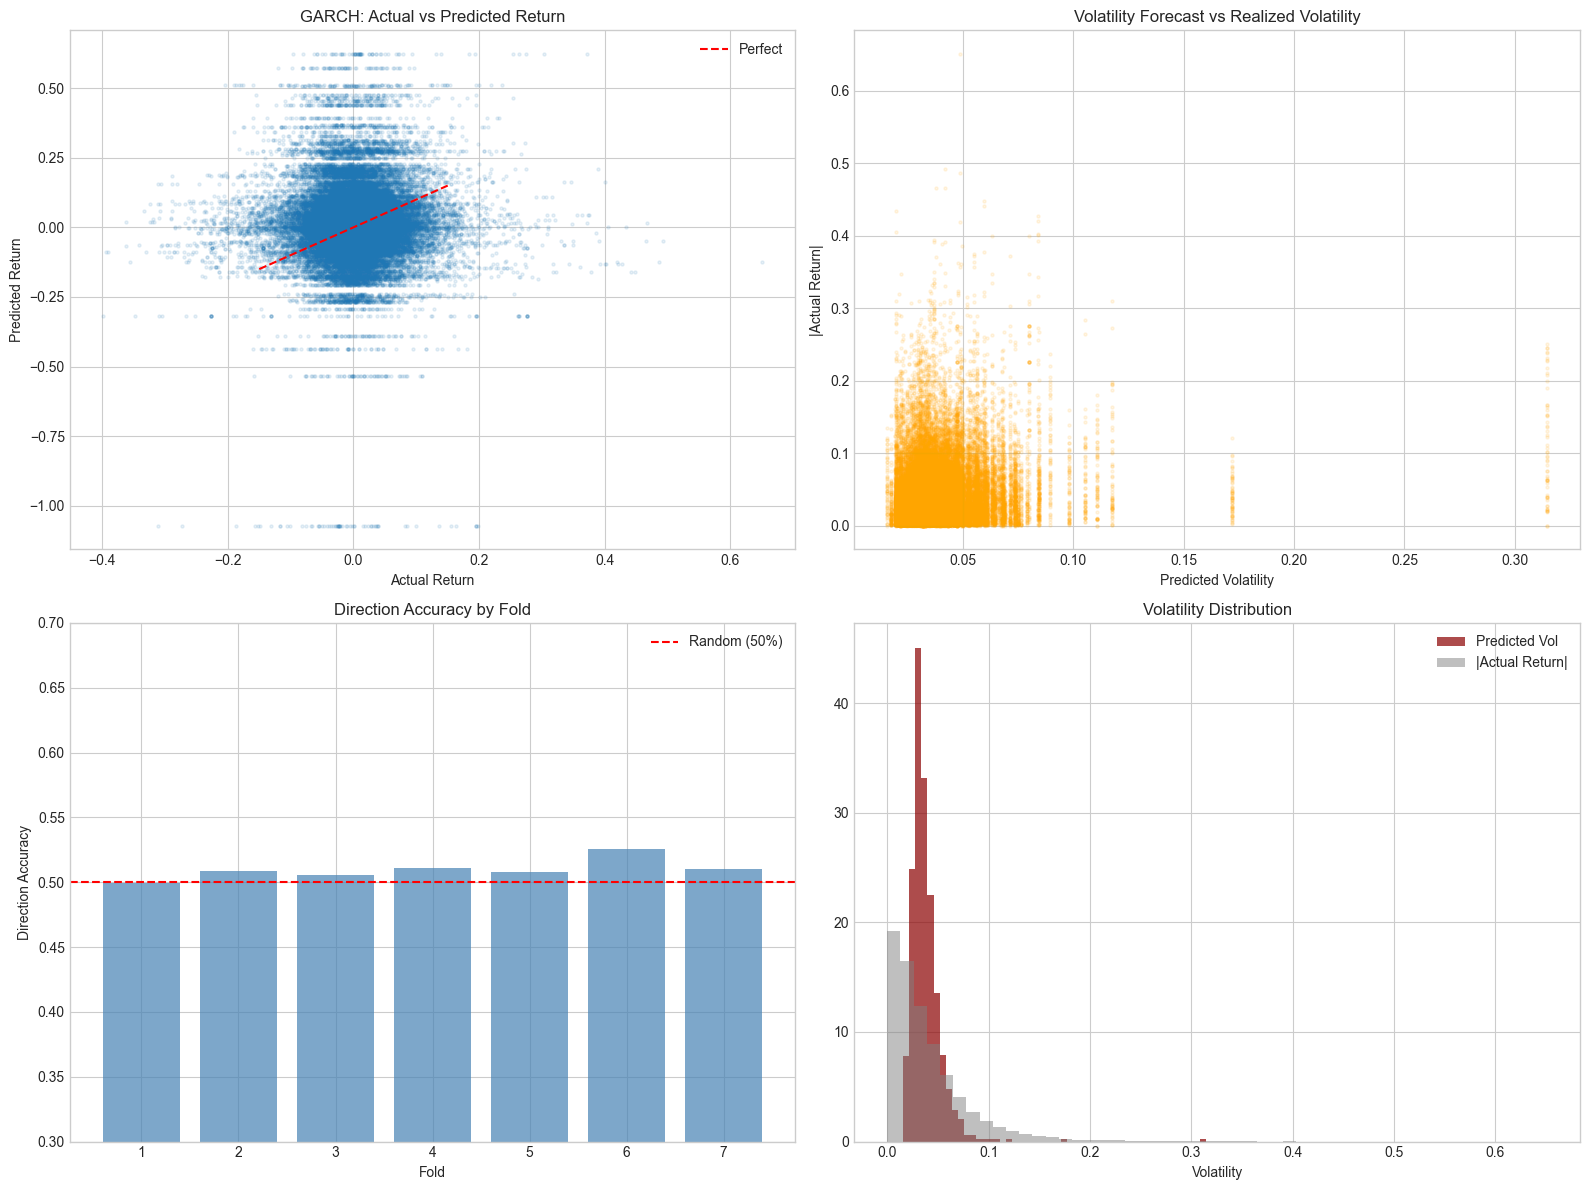


Correlation(predicted_vol, |actual_return|): 0.153
  > 0 means GARCH captures volatility correctly — useful for position sizing


In [35]:
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Actual vs Predicted returns
    axes[0, 0].scatter(all_preds["actual"], all_preds["predicted"], alpha=0.1, s=5)
    axes[0, 0].plot([-0.15, 0.15], [-0.15, 0.15], "r--", label="Perfect")
    axes[0, 0].set_xlabel("Actual Return")
    axes[0, 0].set_ylabel("Predicted Return")
    axes[0, 0].set_title("GARCH: Actual vs Predicted Return")
    axes[0, 0].legend()
    
    # 2. Predicted volatility vs actual absolute returns
    axes[0, 1].scatter(all_preds["predicted_vol"], all_preds["actual"].abs(),
                       alpha=0.1, s=5, color="orange")
    axes[0, 1].set_xlabel("Predicted Volatility")
    axes[0, 1].set_ylabel("|Actual Return|")
    axes[0, 1].set_title("Volatility Forecast vs Realized Volatility")
    
    # 3. Direction accuracy by fold
    axes[1, 0].bar(results_df["fold"], results_df["direction_accuracy"],
                   color="steelblue", alpha=0.7)
    axes[1, 0].axhline(0.5, color="red", linestyle="--", label="Random (50%)")
    axes[1, 0].set_xlabel("Fold")
    axes[1, 0].set_ylabel("Direction Accuracy")
    axes[1, 0].set_title("Direction Accuracy by Fold")
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0.3, 0.7)
    
    # 4. Volatility distribution
    axes[1, 1].hist(all_preds["predicted_vol"], bins=50, density=True,
                    alpha=0.7, color="darkred", label="Predicted Vol")
    axes[1, 1].hist(all_preds["actual"].abs(), bins=50, density=True,
                    alpha=0.5, color="gray", label="|Actual Return|")
    axes[1, 1].set_xlabel("Volatility")
    axes[1, 1].set_title("Volatility Distribution")
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Correlation between predicted vol and |actual return|
    vol_corr = all_preds["predicted_vol"].corr(all_preds["actual"].abs())
    print(f"\nCorrelation(predicted_vol, |actual_return|): {vol_corr:.3f}")
    print("  > 0 means GARCH captures volatility correctly — useful for position sizing")

## Step 5 — GARCH Parameters Analysis

In [20]:
# Analyze fitted GARCH parameters across tickers
importance = model.feature_importance()
if importance is not None:
    print("Average GARCH Parameters Across Tickers:")
    print("="*50)
    for name, val in importance.items():
        if name != "Fitted tickers":
            print(f"  {name:30s}: {val:.6f}")
        else:
            print(f"  {name:30s}: {int(val)}")
    
    # Check persistence (alpha + beta)
    alpha_vals = []
    beta_vals = []
    for ticker, result in model.models.items():
        params = result.params
        for pname in params.index:
            if 'alpha' in pname.lower():
                alpha_vals.append(params[pname])
            elif 'beta' in pname.lower():
                beta_vals.append(params[pname])
    
    if alpha_vals and beta_vals:
        avg_persistence = np.mean(alpha_vals) + np.mean(beta_vals)
        print(f"\n  Average persistence (α + β): {avg_persistence:.3f}")
        print(f"  {'High' if avg_persistence > 0.9 else 'Moderate'} volatility persistence")
        print(f"  (values close to 1.0 = volatility shocks are very persistent)")

Average GARCH Parameters Across Tickers:
  Fitted tickers                : 120
  nu                            : 7.612928
  beta[1]                       : 0.831686
  Close[1]                      : 0.793781
  omega                         : 0.488349
  alpha[1]                      : 0.119232
  Const                         : 0.070713

  Average persistence (α + β): 0.951
  High volatility persistence
  (values close to 1.0 = volatility shocks are very persistent)


## Step 6 — Save Model & Predictions

In [14]:
# Save the last fold's model
model.save(MODELS_DIR / "garch_model.joblib")
print(f"✅ GARCH model saved to {MODELS_DIR / 'garch_model.joblib'}")

# Save OOF predictions for ensemble stacking
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    all_preds.to_parquet(DATA_DIR / "processed" / "garch_predictions.parquet")
    print(f"✅ Predictions saved ({len(all_preds):,} samples)")
    print(f"   Avg direction accuracy: {results_df['direction_accuracy'].mean():.1%}")
    print(f"   Avg predicted volatility: {results_df['avg_predicted_vol'].mean():.4f}")

gc.collect()
print("\n✅ GARCH training complete!")

  Saved garch (120 tickers) to /Users/anto/Trading_Project/masters_trading_ai/models/garch_model.joblib
✅ GARCH model saved to /Users/anto/Trading_Project/masters_trading_ai/models/garch_model.joblib
✅ Predictions saved (50,552 samples)
   Avg direction accuracy: 51.0%
   Avg predicted volatility: 0.0380

✅ GARCH training complete!


## ✅ GARCH Training Complete!

**Key takeaways:**
- GARCH captures volatility clustering — large moves follow large moves
- Student-t innovations model fat tails better than Gaussian
- Volatility forecasts useful for position sizing (less exposure when vol is high)
- Mean return forecast provides a diversified signal for the ensemble
- High persistence (α + β ≈ 0.95) is typical for equity markets

**Next:** Proceed to **Notebook 07 — XGBoost Model**

---
*Educational project. Not financial advice.*